# Buổi 10 — Làm sạch và dữ liệu thiếu

**Một câu:** trước khi điền chỗ thiếu, phải tìm cho đủ chỗ thiếu (kể cả dòng không tồn tại và số trông như số đo mà không phải), hiểu
**vì sao** nó mất, chấm cách điền trên cả lỗ ngắn lẫn lỗ dài, và chỉ điền lỗ ngắn bằng cách không nhìn tương lai.

Tình huống: nhiệt độ trạm khí tượng sân bay Nội Bài năm 2024, mỗi 30 phút một mốc, cùng bụi mịn 12 trạm Bắc Kinh. `isna()` báo "gần như
đủ". Thật ra thiếu bao nhiêu, cái gì đang giả làm số đo, và nên lấp thế nào?

| Phần | Câu hỏi |
|---|---|
| 1 | Vì sao `isna()` báo gần đủ mà dữ liệu vẫn thủng? |
| 2 | Số bị mất vì lý do gì, và lý do đó có làm lệch kết quả không? |
| 3 | Những con số nào không phải số đo? |
| 4 | Bảy cách điền: cách nào hợp lỗ nào? |
| 5 | Chấm cách điền thế nào cho trung thực? |
| 6 | Làm sạch thế nào để không rò rỉ tương lai? |

## 0. Dữ liệu

**Bộ dữ liệu Beijing Multi-Site Air Quality.** Nồng độ chất ô nhiễm **theo giờ** ở 12 trạm quan trắc Bắc Kinh từ 1/3/2013 tới 28/2/2017, ghép với thời tiết của
trạm khí tượng gần nhất. Tệp tải về là một zip chứa một zip khác; bên trong là 12 tệp CSV, mỗi trạm một tệp, mỗi dòng là
**một giờ** (35.064 dòng một trạm). Giờ bị mất đo để trống (NaN).

Nguồn: Chen, S. (2017). Beijing Multi-Site Air Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5RK5G. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `year`, `month`, `day`, `hour` | thời điểm đo, giờ Bắc Kinh |
| `PM2.5`, `PM10` | nồng độ bụi mịn, µg/m³ |
| `SO2`, `NO2`, `CO`, `O3` | các khí ô nhiễm, µg/m³ |
| `TEMP`, `PRES`, `DEWP` | nhiệt độ (°C), áp suất (hPa), điểm sương (°C) |
| `RAIN`, `wd`, `WSPM` | lượng mưa (mm), hướng gió, tốc độ gió (m/s) |
| `station` | tên trạm |

**Bộ dữ liệu NOAA GHCNh — trạm Nội Bài (VMI0000VVNB), 2024.** Bản tin quan trắc thời tiết **thô** của trạm sân bay Nội Bài năm 2024, do Cơ quan Khí quyển và Đại dương Mỹ (NOAA)
gom từ mạng trao đổi quốc tế (GHCNh — Global Historical Climatology Network hourly). Trạm báo **mỗi 30 phút** nhưng có
lúc thiếu, lúc báo thêm bản tin đặc biệt. Tệp Parquet 17.319 dòng, 329 cột: mỗi đại lượng đo có một cột giá trị và năm
cột đi kèm (mã chất lượng, mã nguồn…). Giờ ghi theo **UTC**.

Nguồn: Menne, M.J. et al. (2023). Global Historical Climatology Network-Hourly (GHCNh). NOAA NCEI. doi:10.25921/jp3d-3v19. Giấy phép CC0 1.0 (NOAA).

| Cột | Nghĩa |
|---|---|
| `DATE` | thời điểm bản tin, **UTC** |
| `temperature` | nhiệt độ không khí, °C |
| `dew_point_temperature`, `relative_humidity` | điểm sương (°C), độ ẩm tương đối (%) |
| `visibility`, `wind_speed` | tầm nhìn (km), tốc độ gió (m/s) |
| `temperature_Quality_Code` | mã chất lượng NOAA gắn cho giá trị: 2/6 đáng ngờ, 3/7 sai; mỗi cột đo có một cột `_Quality_Code` như vậy |

**Bộ dữ liệu Open-Meteo Historical Weather (ERA5) — Hà Nội.** Thời tiết **theo giờ** 2023–2024 tại điểm lưới trung tâm Hà Nội, lấy từ Open-Meteo (dữ liệu tái phân tích ERA5 của
châu Âu — mô hình thời tiết "chạy lại quá khứ" có ghép số đo, nên không có lỗ hổng). Tệp CSV có 3 dòng đầu là thông tin
điểm lưới, rồi mới tới bảng. Giờ ghi theo **UTC**.

Nguồn: Weather data by Open-Meteo.com (https://open-meteo.com/), mô hình ERA5 (Copernicus Climate Change Service). Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `time` | giờ, **UTC** |
| `temperature_2m (°C)`, `relative_humidity_2m (%)` | nhiệt độ và độ ẩm ở độ cao 2 m |
| `precipitation (mm)`, `wind_speed_10m (km/h)`, `wind_direction_10m (°)` | lượng mưa, tốc độ và hướng gió ở độ cao 10 m |

Ô dưới tải dữ liệu (10 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "uci-beijing-air": ("b04da438b2f331ac0ffd45aebdfec0d20d2367feb5f6948c4b1f7ce1191e33c4", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/uci-beijing-air/beijing+multi+site+air+quality+data.zip",
        "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip",
    ]),
    "ghcnh-noi-bai-2024": ("1c67048928d447f340d75fffb187e4618fddc3892f971e9e9b4cab2ce2e320e2", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/ghcnh-noi-bai-2024/GHCNh_VMI0000VVNB_2024.parquet",
        "https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2024/parquet/GHCNh_VMI0000VVNB_2024.parquet",
    ]),
    "open-meteo-ha-noi-2023-2024": ("10146f74574963a69550ca45a868575e5b127148d01fd7ba4c0462b52e2459cd", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/open-meteo-ha-noi-2023-2024/open-meteo-ha-noi-2023-2024.csv",
        "https://archive-api.open-meteo.com/v1/archive?latitude=21.0285&longitude=105.8542&start_date=2023-01-01&end_date=2024-12-31&hourly=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m&timezone=UTC&models=era5&format=csv",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import io
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.structural import UnobservedComponents

warnings.simplefilter("ignore")
COT_DO = ["temperature", "dew_point_temperature", "relative_humidity", "visibility", "wind_speed"]

goc = pd.read_parquet(lay("ghcnh-noi-bai-2024"))            # tệp thô, giữ nguyên kiểu dữ liệu (phần 3)
tho = pd.DataFrame(index=pd.DatetimeIndex(pd.to_datetime(goc["DATE"]), name="thoi_gian"))
for cot in COT_DO:
    tho[cot] = pd.to_numeric(goc[cot], errors="coerce").to_numpy()             # ép kiểu số
    tho[f"ma_{cot}"] = goc[f"{cot}_Quality_Code"].astype("string").fillna("").to_numpy()   # cờ chất lượng
tho = tho.sort_index()

om = pd.read_csv(lay("open-meteo-ha-noi-2023-2024"), skiprows=3, index_col="time", parse_dates=True)
hx = om["temperature_2m (°C)"]                              # "trạm hàng xóm": nhiệt độ mô hình cho Hà Nội, giờ UTC

bk_tho = {}                                                  # zip chứa zip chứa 12 CSV, mỗi trạm một tệp
with zipfile.ZipFile(lay("uci-beijing-air")) as z:
    with zipfile.ZipFile(io.BytesIO(z.read("PRSA2017_Data_20130301-20170228.zip"))) as z2:
        for ten in sorted(t for t in z2.namelist() if t.endswith(".csv")):
            bk_tho[ten.split("/")[-1].split("_")[2]] = pd.read_csv(z2.open(ten))
bk = pd.DataFrame({tram: pd.Series(d["PM2.5"].to_numpy(), index=pd.to_datetime(d[["year", "month", "day", "hour"]]))
                   for tram, d in bk_tho.items()}).sort_index()

print(f"Nội Bài: {len(tho):,} dòng, {goc.shape[1]} cột | Open-Meteo: {len(hx):,} giờ | Bắc Kinh: {bk.shape[0]:,} giờ × {bk.shape[1]} trạm")

## 1. `isna()` không thấy dòng không tồn tại: dựng lưới trước mọi việc

**Vấn đề.** Lệnh đầu tiên ai cũng chạy là `df.isna().sum()`. Nó chỉ đếm ô rỗng trong những dòng **có mặt**.

> **thiếu mốc / thiếu giá trị** · *missing timestamp / missing value*
>
> - **Là gì:** thiếu mốc là cả dòng không tồn tại; thiếu giá trị là có dòng nhưng ô rỗng (NaN).
> - **Ví dụ:** tệp đo mỗi 30 phút mà không có dòng 01:00 là thiếu mốc; dòng 02:00 có mặt nhưng nhiệt độ NaN là thiếu giá trị.
> - **Để làm gì:** `isna()` chỉ thấy loại thứ hai; không dựng lưới thì mô hình tưởng dữ liệu liền mạch.
>
> 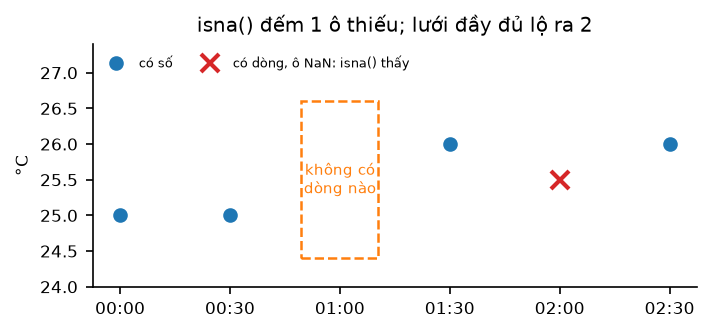

> **lỗ hổng, độ dài lỗ** · *gap, gap length*
>
> - **Là gì:** một đoạn liền các mốc không có số; độ dài là số bước của đoạn đó.
> - **Ví dụ:** 10:00, 10:30, 11:00 đều NaN, 09:30 và 11:30 có số: một lỗ dài 3 bước (1,5 giờ).
> - **Để làm gì:** quyết định lấp hay để trống: lỗ một bước gần như đoán được, lỗ hai ngày thì không.

**Lý do.** Năm dòng 00:00, 00:30, 01:30, 02:00 (NaN), 02:30: `isna()` báo 1, nhưng mốc 01:00 không có dòng nào. Dựng đủ mọi mốc rồi
`reindex` thì mốc đó hiện ra thành NaN. `reindex` báo lỗi nếu có hai dòng cùng thời điểm, nên kiểm mốc trùng trước.

**Kết quả.**

In [ ]:
bang = pd.Series([25, 25, 26, np.nan, 26],
                 index=pd.to_datetime(["2024-01-01 00:00", "2024-01-01 00:30", "2024-01-01 01:30", "2024-01-01 02:00", "2024-01-01 02:30"]))
print("ví dụ tay: isna()", bang.isna().sum(), "| sau reindex lên lưới", bang.reindex(pd.date_range(bang.index.min(), bang.index.max(), freq="30min")).isna().sum())

luoi = pd.date_range(tho.index.min(), tho.index.max(), freq="30min")
print(f"mốc trùng {tho.index.duplicated().sum()} | mốc trên lưới {len(luoi):,} | dòng có {len(tho):,} | "
      f"thiếu mốc {len(luoi.difference(tho.index))} | isna() trên 5 cột đo {tho[COT_DO].isna().sum().sum()}")


def do_dai_lo(y):
    # độ dài (số bước) của từng đoạn NaN liền nhau
    thieu = y.isna()
    nhom = (thieu != thieu.shift()).cumsum()[thieu]
    return nhom.groupby(nhom).size().reset_index(drop=True)


y = tho["temperature"].reindex(luoi)                        # chuỗi chính, trên lưới đầy đủ
dai = do_dai_lo(y)
print(f"nhiệt độ: {len(dai)} lỗ, {(dai == 1).mean():.1%} dài 1 bước, dài nhất {dai.max()} bước = {dai.max() / 2:g} giờ")

thang = pd.Series(1, index=luoi.difference(tho.index)).resample("MS").sum()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 2.8))
a1.bar(thang.index.month, thang.to_numpy())
a1.set(xlabel="tháng 2024", ylabel="số mốc không có dòng", title="Thiếu mốc dồn vào vài tháng")
a2.hist(dai, bins=np.arange(1, dai.max() + 2) - 0.5, color="tab:orange")
a2.set(xlabel="độ dài lỗ (bước 30 phút)", ylabel="số lỗ", title="Phần lớn lỗ dài một bước")
plt.show()

Lưới cả năm có 17.568 mốc, tệp chỉ có 17.319 dòng: 249 mốc không hề tồn tại, trong khi `isna()` trên năm cột đo chỉ thấy 2 ô.
Thiếu mốc dồn vào vài tháng (dấu hiệu sự cố hệ thống); hai phần ba số lỗ dài một bước, lỗ dài nhất 8 giờ.

Cùng họ: doanh số 0 ngày hết hàng là **thiếu**, không phải nhu cầu bằng 0; học từ số 0 đó, mô hình dự báo thấp, nhập ít, lại hết hàng.

**Bài học.** Kiểm mốc trùng, dựng lưới đầy đủ rồi `reindex` trước mọi việc khác; đếm thiếu trên lưới, không trên tệp.

## 2. MNAR làm lệch dù điền kiểu gì — nên phải kiểm cơ chế bằng số

**Vấn đề.** Điền được hay không phụ thuộc **vì sao** số bị mất (Rubin, 1976), không phụ thuộc cách điền giỏi tới đâu.

> **MCAR / MAR / MNAR** · *missing completely at random / at random / not at random*
>
> - **Là gì:** ba lý do số bị mất: MCAR do may rủi; MAR do một thứ **khác đã đo được** (mùa, gió); MNAR do **chính giá trị** bị mất.
> - **Ví dụ:** mất mạng vài phút là MCAR; trạm hay hỏng mùa mưa là MAR; cảm biến bụi tắt khi bụi quá cao là MNAR.
> - **Để làm gì:** biết điền được tới đâu: MCAR điền thoải mái, MAR điền được nếu dùng thứ giải thích việc mất, MNAR điền kiểu gì cũng lệch.
>
> 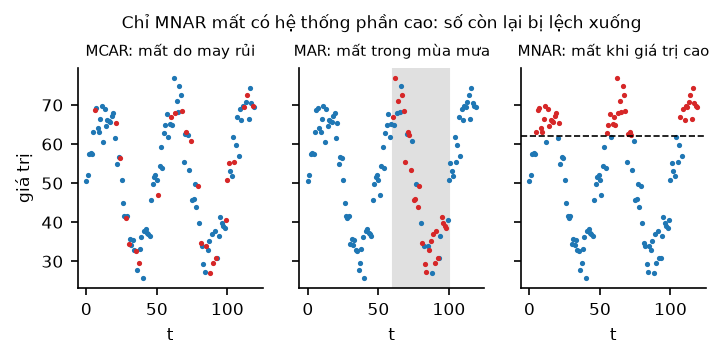

> **PM2.5** · *particulate matter ≤ 2.5 µm*
>
> - **Là gì:** bụi mịn đường kính dưới 2,5 micromet, đo bằng microgam trên mét khối không khí (µg/m³).
> - **Ví dụ:** 80 µg/m³ là ô nhiễm nặng.
> - **Để làm gì:** chuỗi thứ hai của buổi: 12 trạm đo cùng lúc nên kiểm được "trạm mất số lúc bụi cao hay thấp".

**Lý do.** Bốn giờ PM2.5 thật 10, 20, 30, 40; cảm biến tắt khi trên 30. Ba số còn lại không cách nào cho ra 40, nên mọi cách điền đều
lệch xuống. Trên dữ liệu thật, kiểm gián tiếp: khi một trạm mất số, bụi ở các trạm **khác** cao hay thấp hơn thường lệ?

**Kết quả.**

In [ ]:
print("ví dụ tay: trung bình thật", np.mean([10, 20, 30, 40]), "| sau khi điền bằng trung bình phần còn lại", np.mean([10, 20, 30, 20]))

rng = np.random.default_rng(0)                              # mô phỏng: 5.000 điểm hình chuông, cảm biến tắt khi > 1
moc = pd.date_range("2024-01-01", periods=5000, freq="30min")
that = pd.Series(rng.normal(0, 1, 5000), index=moc)
mcar = that.mask(pd.Series(rng.random(5000) < 0.1, index=moc))
mnar = that.mask(that > 1.0)
noi = lambda s: s.interpolate(limit_direction="both")       # noqa: E731  (nội suy tuyến tính)
print(f"mô phỏng: thật {that.mean():.3f} | điền sau MCAR {noi(mcar).mean():.3f} | điền sau MNAR {noi(mnar).mean():.3f} "
      f"(mất {mnar.isna().mean():.1%})")


def bang_chung_mnar(bang, tram):
    khac = bang.drop(columns=[tram]).mean(axis=1)            # bụi trung bình 11 trạm còn lại
    thieu = bang[tram].isna()
    return (f"{tram:<9} thiếu {thieu.mean():.2%} | các trạm khác khi thiếu {khac[thieu].mean():.1f}, khi có "
            f"{khac[~thieu].mean():.1f} µg/m³ | chênh {khac[thieu].mean() / khac[~thieu].mean() - 1:+.1%}")


for tram in ["Dongsi", "Guanyuan", "Wanliu"]:
    print(bang_chung_mnar(bk, tram))

ty_le = bk.isna().groupby(bk.index.to_period("M")).mean() * 100
print(f"Bắc Kinh: thiếu trung bình {bk.isna().mean().mean():.2%}, tháng-trạm tệ nhất {ty_le.to_numpy().max():.1f}%")
fig, ax = plt.subplots(figsize=(10, 3))
anh = ax.imshow(ty_le.to_numpy().T, aspect="auto", cmap="magma_r", vmin=0, vmax=20)
ax.set_yticks(range(12), ty_le.columns, fontsize=7)
ax.set(xlabel="tháng thứ mấy từ 3/2013", title="Thiếu đi thành từng mảng theo trạm và theo tháng")
plt.colorbar(anh, ax=ax, label="% giờ thiếu")
plt.show()

Mô phỏng: MNAR mất 16,2% số điểm, toàn phía cao; điền xong trung bình −0,30 thay vì −0,005, còn MCAR gần như không lệch. Dữ liệu
thật: khi Dongsi thiếu, các trạm khác còn **thấp hơn** 3,0% (hai trạm kia cũng âm): không có dấu hiệu MNAR. Và "thiếu 2,08%" che mất
những tháng một trạm mất gần nửa số giờ.

**Bài học.** Kiểm cơ chế thiếu bằng số theo cả hai chiều, đừng giả định; báo tỷ lệ thiếu theo trạm và theo tháng, không chỉ một con
số chung.

## 3. Không có NaN mà số vẫn sai: mã, trần, làm tròn, kẹt, và cột số lưu dạng chữ

**Vấn đề.** Không có ô rỗng, không có lỗi nào báo ra, mà con số vẫn không phải số đo.

> **mã trá hình (sentinel)** · *sentinel value*
>
> - **Là gì:** con số quy ước đặt vào ô dữ liệu để báo điều gì đó, không phải số đo.
> - **Ví dụ:** tầm nhìn 9,999 km trong bản tin sân bay nghĩa là "từ 10 km trở lên": tầm nhìn thật có thể là 30 km.
> - **Để làm gì:** tránh tính trung bình, xu hướng trên một con số vốn là mã.

> **trần cảm biến** · *sensor ceiling*
>
> - **Là gì:** giá trị lớn nhất cảm biến ghi được; thật có thể cao hơn.
> - **Ví dụ:** độ ẩm dừng ở 100%: sương mù dày hay mỏng đều ghi 100.
> - **Để làm gì:** biết chỗ nào số đo bị cắt ngọn, đừng coi đó là giá trị thật.

> **độ phân giải** · *resolution*
>
> - **Là gì:** bước nhỏ nhất giữa hai giá trị cảm biến ghi được.
> - **Ví dụ:** nhiệt độ 25,6 → 26,4 °C, ghi tới 1 °C thành 26, 26, 26: đổi 0,8 °C mà không thấy.
> - **Để làm gì:** đặt ngưỡng "đứng yên" đúng: độ phân giải thô thì đoạn lặp dài là chuyện thường.

> **cảm biến đứng yên (stuck sensor)** · *stuck sensor*
>
> - **Là gì:** cảm biến kẹt, ghi lặp một giá trị nhiều giờ liền.
> - **Ví dụ:** 26,0; 26,0; … suốt 33 giờ, qua cả ngày lẫn đêm.
> - **Để làm gì:** loại những đoạn không phải số đo trước khi học mô hình.
>
> 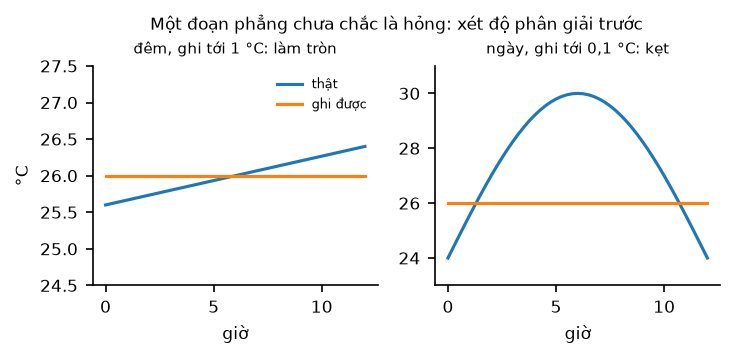

> **cờ chất lượng** · *quality flag*
>
> - **Là gì:** mã nguồn dữ liệu gắn kèm mỗi số đo, nói nó qua kiểm tra hay đáng ngờ.
> - **Ví dụ:** GHCNh: `1` qua mọi kiểm tra, `2` đáng ngờ, `3` sai; `4` chỉ mới qua kiểm giới hạn thô, không phải lỗi.
> - **Để làm gì:** loại số sai theo chính nguồn, thay vì tự đoán.

**Lý do.** Mỗi thủ phạm để lại dấu vết: mã là một giá trị chiếm tỷ lệ lớn bất thường; trần là cột dồn ở mép phải; độ phân giải thô là
ít giá trị khác nhau; kẹt là đoạn lặp dài hơn mức độ phân giải giải thích được. Cột số lưu dạng chữ thì `min()`/`max()` so theo thứ tự
chữ cái.

**Kết quả.**

In [ ]:
rh = goc["relative_humidity"]
print(f"tệp gốc: độ ẩm kiểu {rh.dtype} → min {rh.min()!r}, max {rh.max()!r} | sau ép kiểu: {tho['relative_humidity'].min():g} → {tho['relative_humidity'].max():g}")
print(f"tầm nhìn = 9,999 km: {(tho['visibility'] == 9.999).mean():.1%} số dòng | độ ẩm = 100%: {(tho['relative_humidity'] == 100).mean():.1%}")

t = tho["temperature"].dropna()
gia_tri = np.sort(t.unique())
print(f"nhiệt độ: {gia_tri.size} giá trị khác nhau, bước nhỏ nhất {np.diff(gia_tri).min()} °C, nguyên {(t % 1 == 0).mean():.0%}, "
      f"dải {t.min():g}–{t.max():g} °C")


def doan_mac_ket(y, toi_thieu):
    # các đoạn giá trị lặp liên tiếp dài ≥ toi_thieu bước
    v = y.dropna()
    nhom = (v != v.shift()).cumsum()
    dem = v.groupby(nhom).agg(so_buoc="size", gia_tri="first")
    dem["bat_dau"] = v.groupby(nhom).apply(lambda s: s.index[0])
    return dem[dem["so_buoc"] >= toi_thieu].sort_values("so_buoc", ascending=False).reset_index(drop=True)


for nguong in (24, 36):
    print(f"ngưỡng {nguong} bước ({nguong // 2} giờ): {len(doan_mac_ket(tho['temperature'], nguong))} đoạn đứng yên")
print(doan_mac_ket(tho["temperature"], 36).head(3).to_string(index=False))

MA_NGHI_NGO = {"2", "3", "6", "7", "f", "o"}                 # bảng 3 tài liệu GHCNh; "4" KHÔNG phải lỗi
print("mã chất lượng nhiệt độ:", tho["ma_temperature"].value_counts().to_dict())
cot_do = [c for c in goc.columns if not c.endswith(("_Measurement_Code", "_Quality_Code", "_Report_Type", "_Source_Code", "_Source_Station_ID"))]
print(f"cột rỗng hoàn toàn: {sum(goc[c].isna().all() for c in cot_do)} trên {len(cot_do)} cột")

Độ ẩm trong tệp gốc là chữ nên "min" là `'100'`, "max" là `'94'`. Hơn một phần ba số dòng tầm nhìn là mã 9,999; 5,7% số dòng độ ẩm
chạm trần. Nhiệt độ chỉ có số nguyên (độ phân giải 1 °C), nên ngưỡng 12 giờ bắt tới 24 đoạn "đứng yên", phần lớn chỉ là đêm ít đổi
nhiệt; ngưỡng 18 giờ còn 2 đoạn, dài nhất 33,5 giờ đúng 26,0 °C. Cờ: 7 dòng mã `2` (loại), 9 dòng mã `4` (không phải lỗi, giữ).

**Bài học.** In kiểu và min/max ngay sau khi đọc; xem histogram tìm mã và trần; đo độ phân giải trước khi gọi đoạn lặp là hỏng; tra
bảng cờ của nguồn. Đổi số hỏng thành NaN kèm cờ, đừng xoá cả dòng khi chỉ một cột có vấn đề.

## 4. Lỗ ngắn điền kiểu gì cũng gần đúng; lỗ dài cần cách mang theo hình dạng

**Vấn đề.** Có nhiều cách lấp một lỗ; cách nào đúng tuỳ lỗ dài hay ngắn, chuỗi có nhịp ngày không, có nguồn tương quan không, và có được
nhìn tương lai không.

> **điền dữ liệu (imputation)** · *imputation*
>
> - **Là gì:** ước lượng rồi điền vào chỗ thiếu.
> - **Ví dụ:** 10, (thiếu), 14 → nội suy tuyến tính điền 12.
> - **Để làm gì:** nhiều mô hình không chạy được với NaN; nhưng số điền là số đoán, không phải số đo.
>
> 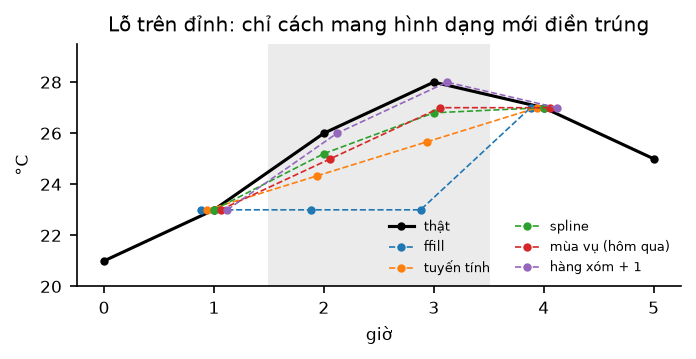

> **nhân quả (cách điền)** · *causal imputation*
>
> - **Là gì:** cách điền chỉ dùng dữ liệu **trước** chỗ đang điền.
> - **Ví dụ:** `ffill` (lấy số gần nhất phía trước) là nhân quả; nội suy hai phía nối với số phía sau nên không.
> - **Để làm gì:** chỉ cách nhân quả mới dùng được khi dự báo thật, lúc tương lai chưa có.
>
> 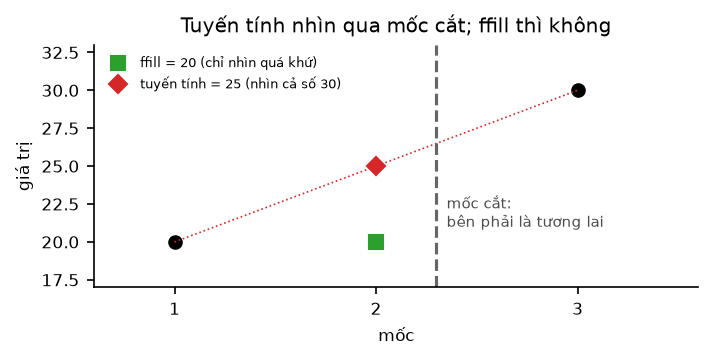

> **spline** · *cubic spline*
>
> - **Là gì:** đường cong trơn bậc 3 nối qua các điểm lân cận.
> - **Ví dụ:** 21, 23, ?, ?, 27, 25 → spline điền 25,2 và 26,8, cong hơn đường thẳng.
> - **Để làm gì:** lấp lỗ ngắn trên chuỗi rất trơn; ở lỗ dài đường cong dễ vọt lố.

> **Kalman smoother**
>
> - **Là gì:** khớp một mô hình chuỗi (mức đổi dần + nhịp ngày) rồi ước lượng giá trị ở ô thiếu từ cả quá khứ lẫn tương lai.
> - **Ví dụ:** lỗ 48 giờ: mô hình biết nhịp ngày nên điền một đường lên xuống theo ngày, không phải đường phẳng.
> - **Để làm gì:** một cách điền khá cho mọi độ dài lỗ, khi mô hình hợp với chuỗi; không nhân quả.

**Lý do.** Tuyến tính và spline chỉ biết hai đầu lỗ. Mùa vụ (cùng giờ hôm trước) và trạm hàng xóm biết thêm **hình dạng** của đoạn bị
mất. Ví dụ: hôm nay 21, 23, ?, ?, 27, 25 (thật 26, 28); hôm qua cùng giờ 20, 22, 25, 27, 26, 24; hàng xóm hôm nay y như hôm qua và luôn
thấp hơn trạm ta 1 °C.

**Kết quả.**

In [ ]:
hom_nay = pd.Series([21, 23, np.nan, np.nan, 27, 25.0])
hom_qua = pd.Series([20, 22, 25, 27, 26, 24.0])
tay = {"ffill": hom_nay.ffill(), "tuyến tính": hom_nay.interpolate(), "spline": hom_nay.interpolate(method="spline", order=3),
       "mùa vụ (hôm qua)": hom_nay.fillna(hom_qua), "hàng xóm + 1": hom_nay.fillna(hom_qua + 1)}
for ten, z in tay.items():
    print(f"{ten:<17} điền {z[2]:.2f}; {z[3]:.2f} | sai {abs(z[2] - 26):.2f}; {abs(z[3] - 28):.2f}")


# bảy cách điền, nhận chuỗi có NaN, trả chuỗi đã điền
def dien_ffill(y, **_):
    return y.ffill()                                         # nhân quả; lỗ dài thành đoạn phẳng


def dien_tuyen_tinh(y, **_):
    return y.interpolate(method="linear", limit_direction="both")          # dùng tương lai


def dien_spline(y, **_):
    return y.interpolate(method="spline", order=3, limit_direction="both")  # dùng tương lai, vọt lố ở lỗ dài


def dien_mua_vu(y, chu_ky=48, **_):
    z = y.copy()                                             # cùng giờ ngày trước, lùi tối đa 14 ngày; nhân quả
    for _ in range(14):
        z = z.where(z.notna(), z.shift(chu_ky))
    return z


def dien_trung_binh_gio(y, **_):
    gio = y.index.hour * 100 + y.index.minute                # trung bình cùng giờ của mọi ngày (cả tương lai)
    return y.fillna(y.groupby(gio).transform("mean"))


def dien_kalman(y, chu_ky=48, **_):
    kq = UnobservedComponents(y.to_numpy(float), level="local level",
                              freq_seasonal=[{"period": chu_ky, "harmonics": 2}]).fit(disp=False, maxiter=50)
    return y.fillna(pd.Series(kq.smoother_results.smoothed_forecasts[0], index=y.index))   # KHÔNG dùng fittedvalues


def dien_hang_xom(y, hang_xom=None, **_):
    x = hang_xom.reindex(y.index).interpolate(limit_direction="both")      # hồi quy y = a·x + b trên chỗ cả hai có số
    chung = y.notna() & x.notna()
    a, b = np.polyfit(x[chung].to_numpy(float), y[chung].to_numpy(float), 1)
    return y.fillna(pd.Series(a * x.to_numpy(float) + b, index=y.index))


CACH_DIEN = {"ffill": dien_ffill, "tuyến tính": dien_tuyen_tinh, "spline": dien_spline, "mùa vụ (ngày trước)": dien_mua_vu,
             "trung bình theo giờ": dien_trung_binh_gio, "Kalman smoother": dien_kalman, "hàng xóm (Open-Meteo)": dien_hang_xom}

chung = pd.concat([y.resample("h").mean(), hx], axis=1, keys=["noi_bai", "open_meteo"]).dropna()   # gộp hai mốc 30 phút thành giờ
print(f"Nội Bài × Open-Meteo: r = {chung.corr().iloc[0, 1]:.3f} trên {len(chung):,} giờ cả hai có số")

Lỗ này nằm đúng lúc nhiệt độ lên đỉnh: `ffill` giữ 23 nên sai nhiều nhất (3 và 5), tuyến tính sai 1,67 và 2,33, mùa vụ sai 1 và 1,
hàng xóm trúng cả hai. Nguồn hàng xóm dùng được vì tương quan cao: Nội Bài và Open-Meteo Hà Nội có $r$ = 0,976.

| Cách | Hợp với | Tránh khi | Nhân quả |
|---|---|---|---|
| `ffill` | lỗ rất ngắn; chuỗi bậc thang (giá niêm yết) | lỗ dài: đoạn phẳng giả | có |
| tuyến tính, spline | lỗ ngắn, chuỗi trơn, khi được nhìn cả hai phía | lỗ dài; dự báo thật | không |
| mùa vụ (ngày trước) | nhịp ngày mạnh, lỗ dài | ngày trước cũng thiếu | có |
| trung bình theo giờ | chỉ cần một giá trị "điển hình" | cần đúng diễn biến ngày đó | không |
| Kalman smoother | mọi độ dài, khi mô hình hợp chuỗi | cần nhân quả | không |
| trạm hàng xóm | nguồn tương quan cao, đo cùng lúc | hàng xóm cũng thiếu; tương quan thấp | có, nếu hệ số học từ quá khứ |

**Bài học.** Chọn cách điền theo độ dài lỗ, và luôn biết cách đó có nhìn tương lai không.

## 5. Che điểm và che khối cho thứ hạng ngược nhau

**Vấn đề.** Muốn biết cách điền nào tốt thì phải có đáp án, mà ô thiếu thật thì không có.

> **che nhân tạo** · *artificial masking*
>
> - **Là gì:** xoá những ô đang có số rồi điền lại, để có đáp án mà chấm cách điền.
> - **Ví dụ:** một ngày 20, 21, 23, 25, 26, 25, 23, 21: che bốn số giữa, tuyến tính nối 21 với 23 được MAE 2,75.
> - **Để làm gì:** ô thiếu thật không có đáp án; che nhân tạo là cách duy nhất đo cách điền nào tốt.
>
> 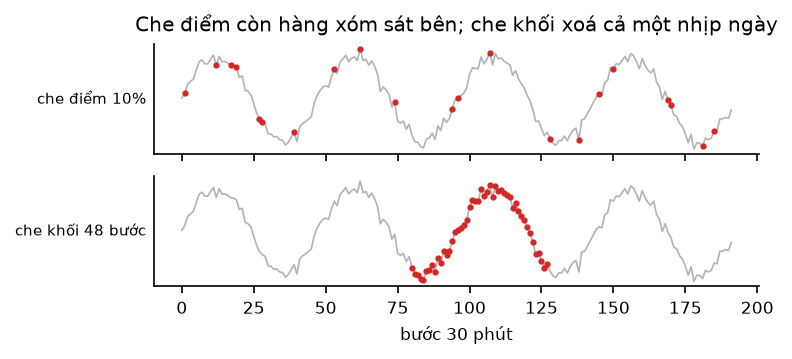

**Lý do.** Che ô đang có số, điền lại, so với số thật. Kiểu che phải giống cách dữ liệu thật bị mất: che rải từng điểm là thi "lỗ một
bước", cảm biến chết hai ngày là bài thi khác hẳn. Nội Bài có cả hai loại lỗ, nên chấm cả hai: che ngẫu nhiên 10% số điểm, và che 5 khối
48 giờ.

**Kết quả.**

In [ ]:
def che_diem(y, ty_le=0.10, seed=0):
    rng = np.random.default_rng(seed)
    co = np.flatnonzero(y.notna().to_numpy())
    z = y.copy()
    z.iloc[rng.choice(co, size=int(len(co) * ty_le), replace=False)] = np.nan
    return z


def che_khoi(y, so_buoc=96, so_khoi=5, seed=0):
    rng = np.random.default_rng(seed)
    z = y.copy()
    for _ in range(so_khoi):
        dau = int(rng.integers(0, len(y) - so_buoc))
        z.iloc[dau:dau + so_buoc] = np.nan
    return z


def cham(that, y_che):
    o_che = that.notna() & y_che.isna()                      # chỉ chấm trên ô bị che
    return {ten: float((ham(y_che, hang_xom=hx)[o_che] - that[o_che]).abs().mean()) for ten, ham in CACH_DIEN.items()}


that = y.dropna()
bang_dien = pd.DataFrame({"che điểm 10%": cham(that, che_diem(that)), "che khối 48 giờ": cham(that, che_khoi(that))})
bang_dien["hạng điểm"] = bang_dien["che điểm 10%"].rank().astype(int)
bang_dien["hạng khối"] = bang_dien["che khối 48 giờ"].rank().astype(int)
print(bang_dien.sort_values("che điểm 10%").round(3).to_string())

che = che_khoi(that)
o_che = that.notna() & che.isna()
dau = che[o_che].index[0]
cua_so = slice(dau - pd.Timedelta("24h"), dau + pd.Timedelta("72h"))
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(that[cua_so], color="k", lw=1.6, label="thật")
for ten in ("ffill", "tuyến tính", "mùa vụ (ngày trước)", "hàng xóm (Open-Meteo)"):
    ax.plot(CACH_DIEN[ten](che, hang_xom=hx)[cua_so].where(o_che[cua_so]), lw=1.2, label=ten)
ax.axvspan(dau, dau + pd.Timedelta("48h"), color="red", alpha=0.06)
ax.set(ylabel="°C", title="Một lỗ 48 giờ: ffill và tuyến tính thành đường phẳng, hàng xóm giữ nhịp ngày")
ax.legend(fontsize=8, ncol=3)
plt.show()

Chỉ đổi kiểu che mà thứ hạng đảo: tuyến tính hạng 1 ở lỗ ngắn (MAE 0,291 °C) nhưng hạng 5 ở lỗ 48 giờ (2,171); hàng xóm đi ngược lại,
hạng 5 lên hạng 1. Spline tệ nhất ở lỗ dài vì vọt lố. Trong hình, `ffill` và tuyến tính thành đường phẳng suốt hai ngày; mô hình học
trên đó sẽ tin nhiệt độ có lúc đứng yên hai ngày liền.

**Bài học.** Che theo đúng những kiểu lỗ dữ liệu thật có, và báo cả hai: cách tốt nhất ở lỗ ngắn có thể tệ ở lỗ dài.

## 6. Điền bằng tương lai là rò rỉ: chỉ điền lỗ ngắn, nhân quả, và xuất cột cờ

**Vấn đề.** Điền xong, backtest đẹp bất thường; hoặc chuỗi có những đoạn hai ngày được "bịa" ra mà sáu tháng sau không ai biết.

> **cột cờ** · *flag column*
>
> - **Là gì:** cột thêm vào để đánh dấu ô nào đã bị điền, bị loại, hay cố ý để trống.
> - **Ví dụ:** `da_dien = True` ở ô 14:30: số 26 ở đó là số điền, không phải số đo.
> - **Để làm gì:** hạ trọng số hoặc bỏ ô đã điền khỏi tập chấm; trả lời "số này từ đâu ra" sáu tháng sau.

> **pipeline**
>
> - **Là gì:** chuỗi bước chạy tự động từ dữ liệu thô tới dữ liệu sạch.
> - **Ví dụ:** đọc → ép kiểu → lưới → cờ → điền lỗ ngắn → báo cáo, chạy lại một lệnh là ra cùng kết quả.
> - **Để làm gì:** làm sạch lặp lại được và kiểm được bằng test, thay vì sửa tay từng ô.

> **SAITS, BRITS**
>
> - **Là gì:** hai mô hình deep learning điền dữ liệu thiếu, học từ nhiều chuỗi cùng lúc (thư viện PyPOTS).
> - **Ví dụ:** trên bộ so sánh TSI-Bench, chúng có lợi khi có hàng chục chuỗi tương quan và thiếu nhiều.
> - **Để làm gì:** biết khi nào đáng dùng: một trạm thiếu vài phần trăm thì hồi quy theo hàng xóm đã đủ tốt.

**Lý do.** Chuỗi 20, NaN, 30: `ffill` điền 20 dù có số 30 hay không; tuyến tính điền 25 **nhờ** số 30 phía sau. Nếu số 30 thuộc tập
kiểm, thông tin tập kiểm đã chảy vào tập học. Kiểm tự động: làm sạch dữ liệu đầy đủ và dữ liệu cắt tại một mốc, so phần trước mốc cắt.
Mốc cắt phải nằm **trong một lỗ**, nếu không bài kiểm im lặng.

**Kết quả.** Pipeline: đưa lên lưới, loại số bị cờ (mã chất lượng, đoạn kẹt ≥ 36 bước), đo **lại** độ dài lỗ, chỉ điền lỗ ≤ 6 bước (3 giờ)
bằng mùa vụ, xuất ba cột cờ.

In [ ]:
def lam_sach(bang, cot="temperature", gioi_han=6, mac_ket=36, cach=dien_mua_vu, dien_het=False):
    luoi_b = pd.date_range(bang.index.min(), bang.index.max(), freq="30min")
    v = bang[cot].reindex(luoi_b)
    nghi = bang[f"ma_{cot}"].reindex(luoi_b).fillna("").isin(MA_NGHI_NGO)          # cờ chất lượng của nguồn
    for _, d in doan_mac_ket(v, mac_ket).iterrows():                                 # đoạn kẹt
        nghi.loc[d["bat_dau"]:d["bat_dau"] + pd.Timedelta("30min") * (d["so_buoc"] - 1)] = True
    sach = v.where(~nghi)                                     # loại TRƯỚC rồi mới đo độ dài lỗ
    thieu = sach.isna()
    nhom = (thieu != thieu.shift()).cumsum()
    do_dai = nhom.map(nhom[thieu].value_counts()).where(thieu, 0)
    dien_duoc = thieu if dien_het else thieu & (do_dai <= gioi_han)
    ket_qua = sach.where(~dien_duoc, cach(sach, hang_xom=hx))
    return pd.DataFrame({cot: ket_qua, "da_dien": dien_duoc & ket_qua.notna(), "nghi_ngo": nghi,
                         "lo_dai_bo_trong": thieu & ~dien_duoc})


sach = lam_sach(tho)
print(f"mốc {len(sach):,} | bị loại vì nghi ngờ {sach['nghi_ngo'].sum()} | đã điền {sach['da_dien'].sum()} | "
      f"để trống có chủ ý {sach['lo_dai_bo_trong'].sum()}")


def kiem_ro_ri(ham, bang, moc_cat):
    # làm sạch trên dữ liệu đầy đủ và trên dữ liệu cắt tại moc_cat; phần trước mốc cắt phải giống hệt
    day = ham(bang).loc[:moc_cat - pd.Timedelta("30min"), "temperature"]
    cat = ham(bang.loc[:moc_cat - pd.Timedelta("30min")])["temperature"]
    lech = (day - cat).abs().max()
    return "PHÁT HIỆN RÒ RỈ" if lech > 1e-9 else "không phát hiện rò rỉ"


nho = tho.iloc[:2000].copy()
nho.iloc[1190:1210, nho.columns.get_loc("temperature")] = np.nan          # khoét một lỗ 20 bước
trong_lo, ngoai_lo = nho.index[1205], nho.index[1500]
for ten, ham in {"điền mọi lỗ bằng tuyến tính": lambda b: lam_sach(b, cach=dien_tuyen_tinh, dien_het=True),
                 "lỗ ≤ 6 bước bằng mùa vụ   ": lambda b: lam_sach(b)}.items():
    print(f"{ten}: cắt trong lỗ → {kiem_ro_ri(ham, nho, trong_lo)} | cắt chỗ liền → {kiem_ro_ri(ham, nho, ngoai_lo)}")

Trên 17.568 mốc: 130 ô bị loại vì nghi ngờ, 198 ô được điền, 181 ô để trống có chủ ý. Bản điền mọi lỗ bằng tuyến tính bị bắt khi cắt
trong lỗ nhưng lọt khi cắt ở chỗ liền; bản đúng sạch ở cả hai. Loại số nghi ngờ **trước** rồi mới đo độ dài lỗ, vì biến số kẹt thành
NaN có thể nối hai lỗ ngắn thành một lỗ dài.

**Bài học.** Chia tập trước, điền bằng cách nhân quả; chỉ điền lỗ ngắn, lỗ dài để NaN; luôn xuất cột cờ cùng dữ liệu; đặt mốc cắt của
bài kiểm rò rỉ trong một lỗ.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Che theo đúng phân bố thật.** Rút độ dài lỗ từ chính phân bố độ dài lỗ của Nội Bài (phần 1), đặt vào vị trí ngẫu nhiên tới
khi che đủ 10% số điểm (seed 0):

In [ ]:
def che_theo_phan_bo(y, dai_lo, ty_le=0.10, seed=0):
    rng = np.random.default_rng(seed)
    z = y.copy()
    while z.isna().mean() < ty_le:
        d = int(rng.choice(dai_lo))
        dau = int(rng.integers(0, len(y) - d))
        z.iloc[dau:dau + d] = np.nan
    return z


bang_dien["che theo phân bố thật"] = cham(that, che_theo_phan_bo(that, dai.to_numpy()))
bang_dien["hạng thật"] = bang_dien["che theo phân bố thật"].rank().astype(int)
print(bang_dien[["hạng điểm", "hạng khối", "che theo phân bố thật", "hạng thật"]].sort_values("hạng thật").round(3).to_string())

Lỗ thật phần lớn dài một bước nên thứ hạng gần với che điểm, nhưng Kalman smoother vượt lên hạng 1 (0,422) trước tuyến tính (0,435):
vài lỗ dài vài giờ đã đủ đổi thứ tự. Chấm theo phân bố thật để chọn cách cho lỗ đang có; vẫn báo che khối cho lỗ dài có thể gặp sau.

**Bài 2 — MAR có cứu được không.** Trạm Dongsi: xoá PM2.5 với xác suất 30% ở những giờ gió mạnh (`WSPM` trên tứ phân vị trên) và 3% ở
giờ khác (seed 0). Gió mạnh thổi bụi đi, nên ô bị xoá vốn là ô bụi thấp: thiếu MAR theo gió. So điền bằng trung bình chung với điền bằng
trung bình trong cùng nhóm gió:

In [ ]:
d = bk_tho["Dongsi"]
pm = pd.Series(d["PM2.5"].to_numpy(), index=bk.index)
gio_gio = pd.Series(d["WSPM"].to_numpy(), index=bk.index)
nhom_gio = pd.qcut(gio_gio, 4, labels=False)                 # 4 nhóm gió, nhóm 3 = mạnh nhất
rng = np.random.default_rng(0)
xoa = pm.notna() & gio_gio.notna() & (rng.random(len(pm)) < np.where(nhom_gio == 3, 0.30, 0.03))
con = pm.mask(xoa)
dien = {"trung bình chung (không dùng gió)": con.fillna(con.mean()),
        "trung bình theo nhóm gió": con.fillna(con.groupby(nhom_gio).transform("mean"))}
print(f"xoá {xoa.sum():,} giờ | PM2.5 thật ở giờ bị xoá {pm[xoa].mean():.1f}, ở giờ còn lại {pm[~xoa].mean():.1f} µg/m³")
for ten, z in dien.items():
    print(f"{ten:<34} MAE {(z[xoa] - pm[xoa]).abs().mean():.1f} | lệch trung bình {(z[xoa] - pm[xoa]).mean():+.1f} µg/m³")

Giờ bị xoá có bụi thật thấp hơn hẳn giờ còn lại (60,5 so với 88,8 µg/m³). Điền bằng trung bình chung lệch lên +28,4 µg/m³;
điền theo nhóm gió gần như hết lệch (−1,9) và MAE giảm từ 62,4 xuống 47,1. MAR cứu được, với điều kiện cách điền dùng đúng thứ giải
thích việc mất.

**Bài 3 — Giá của việc điền sai.** Dự báo naive 1 giờ tới (2 bước 30 phút) trên chuỗi đã làm sạch theo hai cách: (a) nội suy mọi lỗ, (b)
chỉ điền lỗ ≤ 3 giờ. Chấm trên mọi giờ có số, rồi chỉ trên giờ mà cả số thật lẫn số dùng để dự báo đều không phải số điền:

In [ ]:
ban = {"(a) nội suy mọi lỗ": lam_sach(tho, cach=dien_tuyen_tinh, dien_het=True), "(b) chỉ điền lỗ ≤ 3 giờ": sach}
for ten, s in ban.items():
    v, dien_o = s["temperature"], s["da_dien"]
    sai = (v - v.shift(2)).abs()                              # naive: dự báo = giá trị 1 giờ trước
    that_su = ~dien_o & ~dien_o.shift(2, fill_value=True)
    print(f"{ten:<24} MAE mọi giờ có số {sai.mean():.3f} ({sai.notna().sum():,} điểm) | "
          f"chỉ giờ không điền {sai[that_su].mean():.3f} ({sai[that_su].notna().sum():,} điểm)")

Chấm trên mọi giờ, (a) trông tốt nhất (0,579) vì đoạn nội suy thẳng rất dễ đoán, (b) trông tệ hơn (0,602) vì số điền mùa vụ nhảy bậc
ở mép lỗ. Chấm trên giờ không có số điền, hai cách **bằng nhau** (0,585): điền chỉ làm điểm số đổi, không làm dự báo tốt lên. Luôn bỏ ô
đã điền khỏi tập chấm, nhờ cột `da_dien`.

## Tự kiểm

- [ ] Tệp đo mỗi giờ 00:00–23:00 có 21 dòng, 1 dòng có ô NaN: thiếu mấy giờ, `isna()` báo mấy?
- [ ] Phân biệt MCAR, MAR, MNAR bằng một ví dụ cửa hàng; nói cơ chế nào điền kiểu gì cũng lệch.
- [ ] Kể bốn thứ trông như số đo mà không phải, và dấu vết của từng thứ.
- [ ] Giải thích vì sao ngưỡng "đứng yên" phải đặt theo độ phân giải.
- [ ] Giải thích vì sao tuyến tính hạng 1 khi che điểm mà hạng 5 khi che khối.
- [ ] Nói vì sao mốc cắt của bài kiểm rò rỉ phải nằm trong một lỗ.